# Building a GS file from scratch

## A GSPy workshop

You have been handed a folder of airborne geophysical data from a survey in
northeast Wisconsin. There is no documentation. There are no units. There is
nothing telling you what the columns mean or what coordinate system the
data are in.

By the end of this notebook you will have turned that folder into a single,
self-describing NetCDF file that a colleague could pick up in ten years and
still understand.

| | Section | Time |
|---|---|---|
| 1 | What is in the box? | 5 min |
| 2 | Survey metadata from nothing | 15 min |
| 3 | Variable metadata from nothing | 25 min |
| 4 | Prepared metadata, and why systems exist | 10 min |
| 5 | Attaching the rest of the survey | 10 min |
| 6 | Save, reopen, and check the metadata | 10 min |
| 7 | Plotting | 5 min |

**Before you start:** activate the environment and launch Jupyter from the
workshop root folder, so that the relative paths below resolve.

```
conda activate gspy
jupyter lab
```

Cells marked **EXERCISE** contain `...` placeholders that you need to
replace. They will raise an error if you run them unchanged - that is
deliberate. The completed notebook lives in `solutions/`.

*Source data: Minsley, B.J, and others, 2022, Airborne electromagnetic and
magnetic survey data, northeast Wisconsin (ver. 1.1, June 2022): U.S.
Geological Survey data release, https://doi.org/10.5066/P93SY9LI*

In [1]:
import warnings
from os.path import join
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import gspy
from gspy import Dataset, Metadata, Survey

warnings.filterwarnings('ignore')

DATA = 'data/skytem'            # the data we were handed
PREPARED = 'prepared_metadata/skytem'   # metadata prepared earlier, used from section 4
SCRATCH = 'my_metadata'         # everything you generate goes here

Path(SCRATCH).mkdir(exist_ok=True)

print('gspy     ', gspy.__version__)
print('xarray   ', xr.__version__)
assert Path(DATA).is_dir(), 'Run Jupyter from the workshop root folder'

gspy      2.2.8.post1.dev39+g93dc3f2a8
xarray    2025.12.0


---
---
## 1. What is in the box?

Start by looking at what files you actually have.

In [2]:
for path in sorted(Path(DATA).iterdir()):
    print(f'{path.name:<38} {path.stat().st_size / 1e6:>6.1f} MB')

.ipynb_checkpoints                        0.0 MB
bedrock_depth.tif                         0.9 MB
mag_rmf.tif                               1.9 MB
mag_tmi.tif                               1.9 MB
skytem_contractor_data.csv                1.2 MB
skytem_inverted_models.csv                0.5 MB
skytem_processed_data.csv                 0.5 MB
top_bedrock.tif                           0.9 MB
top_dolomite_blocky_lidar.csv             1.1 MB


Four CSV files and four GeoTIFFs. No `.yml`, no `.json`, no readme, no data
dictionary. There is no accompanying metadata with these files.

---
### Exercise 1.1

Have a look inside the raw AEM data file. How many rows and columns are
there, and what are the columns called?

*Hint: `pandas.read_csv`, then `.shape` and `.columns`.*

In [3]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
raw_csv = join(DATA, 'skytem_contractor_data.csv')

df = pd.read_csv(raw_csv)

print(df.shape)
print(list(df.columns))

(500, 150)
['_60Hz_Intensity', 'Alt', 'AngleX', 'AngleY', 'Base_Mag', 'Curr_HM', 'Curr_LM', 'Date', 'DateTime', 'dec', 'DEM', 'Diurnal', 'E_Nad83', 'E_WGS84', 'Fid', 'Flight', 'GdSpeed', 'Height', 'HM_X[0]', 'HM_X[1]', 'HM_X[2]', 'HM_X[3]', 'HM_X[4]', 'HM_X[5]', 'HM_X[6]', 'HM_X[7]', 'HM_X[8]', 'HM_X[9]', 'HM_X[10]', 'HM_X[11]', 'HM_X[12]', 'HM_X[13]', 'HM_X[14]', 'HM_X[15]', 'HM_X[16]', 'HM_X[17]', 'HM_X[18]', 'HM_X[19]', 'HM_X[20]', 'HM_X[21]', 'HM_X[22]', 'HM_X[23]', 'HM_X[24]', 'HM_X[25]', 'HM_X[26]', 'HM_X[27]', 'HM_X[28]', 'HM_X[29]', 'HM_X[30]', 'HM_X[31]', 'HM_Z[0]', 'HM_Z[1]', 'HM_Z[2]', 'HM_Z[3]', 'HM_Z[4]', 'HM_Z[5]', 'HM_Z[6]', 'HM_Z[7]', 'HM_Z[8]', 'HM_Z[9]', 'HM_Z[10]', 'HM_Z[11]', 'HM_Z[12]', 'HM_Z[13]', 'HM_Z[14]', 'HM_Z[15]', 'HM_Z[16]', 'HM_Z[17]', 'HM_Z[18]', 'HM_Z[19]', 'HM_Z[20]', 'HM_Z[21]', 'HM_Z[22]', 'HM_Z[23]', 'HM_Z[24]', 'HM_Z[25]', 'HM_Z[26]', 'HM_Z[27]', 'HM_Z[28]', 'HM_Z[29]', 'HM_Z[30]', 'HM_Z[31]', 'igrf', 'inc', 'Lat', 'Line', 'LM_X[0]', 'LM_X[1]', 'LM

Now ask yourself:

- What are the units of `Alt`? Is it metres or feet?
- `Alt`, `Height` and `DEM` are three different vertical coordinate data. Which is
  height above ground, which is elevation above a datum, and which datum?
- `E_Nad83` and `N_Nad83` are eastings and northings in *some* projection.
  Which one?
- What does `-9999.99` mean, and which columns use it?
- There are 31 columns starting `HM_X[`. What is the second dimension, and
  what are its values?

Nothing in the file answers any of these. This is the problem a GS file
solves: the answers travel *with* the data, in a format software can read.

---
---
## 2. Survey metadata from nothing

GSPy metadata lives at four levels:

- **Survey** - facts about the whole survey: who flew it, when, where, in
  what coordinate reference system, with what instruments.
- **Container** - Groups of datasets
- **Dataset** - facts about one table or raster of numbers, right down to
  each individual variable.
- **Supplementary** - System information, inversion parameters.

You do not have to write either from memory. `metadata_template()` inspects
what you have and writes out a skeleton for you to fill in. Start with the
survey, which needs no data file at all.

In [4]:
template = Survey.metadata_template()
template.dump(join(SCRATCH, 'survey_template.yml'))

print(Path(SCRATCH, 'survey_template.yml').read_text())

dataset_attrs:
    title: ??
    institution: ??
    source: ??
    history: ??
    references: ??
    comment: ??
    conventions: GS 2.0
    type: survey
survey_information:
    contractor_project_number: ??
    contractor: ??
    client: ??
    survey_type: ??
    survey_area_name: ??
    state: ??
    country: ??
    acquisition_start: yyyymmdd
    acquisition_end: yyyymmdd
    dataset_created: yyyymmdd
spatial_ref:
    wkid: ??
    authority: ??
    crs_wkt: ??
    vertical_crs: ??
flightline_information:
    traverse_line_spacing: ??
    traverse_line_direction: ??
    tie_line_spacing: ??
    tie_line_direction: ??
    nominal_line_spacing: ??
    nominal_terrain_clearance: ??
    final_line_kilometers: ??
    traverse_line_numbers: ??
    tie_line_numbers: ??
survey_equipment:
    aircraft: ??
    magnetometer: ??
    spectrometer_system: ??
    radar_altimeter_system: ??
    radar_altimeter_sample_rate: ??
    laser_altimeter_system: ??
    navigation_system: ??
    acquisitio

Every `??` is a question GSPy is asking you. Open
`my_metadata/survey_template.yml` in your editor and have a look - in real
work this is the file you would fill in and keep under version control
alongside the data.

---
### Exercise 2.1

What do you think happens if we hand that template straight back to GSPy
without filling anything in?

In [5]:
try:
    survey = Survey.from_dict(join(SCRATCH, 'survey_template.yml'))
    print('It worked, which is suspicious')
except Exception as e:
    print(f'{type(e).__name__}: {e}')

CRSError: Invalid projection: ??:??: (Internal Proj Error: proj_create: crs not found: ??:??)


> `CRSError: Invalid projection: ??:??`

It fails on the coordinate reference system, and you can see the two `??`
placeholders it choked on. GSPy will not build a survey that cannot say where
on Earth it is.

---
### Exercise 2.2

Fill in the minimum needed to build a survey. Two things are required: `wkid` and `authority` under `spatial_ref`.

What you know about this survey:

- it was flown over **northeast Wisconsin**, and the positions are
  **Wisconsin Transverse Mercator, NAD83**, which is **EPSG:3071**
- elevations are referenced to **NAVD88**
- it was flown by **SkyTEM Canada Inc** for the **U.S. Geological Survey**
  between **2021-01-17** and **2021-02-07**

Note the pattern below: you pass what you know to `metadata_template()`, and
it merges your entries over the skeleton. Anything you leave out comes back
as `??`, so the template doubles as a to-do list.

*Hint: `wkid` is a number, `authority` is a string.

In [6]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
known = {
    'dataset_attrs': {
        'title': 'SkyTEM AEM Survey, Northeast Wisconsin Bedrock Mapping',
        'institution': 'USGS Geology, Geophysics, and Geochemistry Science Center',
    },
    'spatial_ref': {
        'wkid': 3071,
        'authority': 'EPSG',
        'vertical_crs': 'NAVD88',
    },
    'survey_information': {
        'contractor': 'SkyTEM Canada Inc',
        'client': 'U.S. Geological Survey',
        'survey_type': 'EM/Mag',
        'acquisition_start': 20210117,
        'acquisition_end': 20210207,
    },
}

template = Survey.metadata_template(known)
template.dump(join(SCRATCH, 'survey_filled.yml'))

my_survey = Survey.from_dict(template)
my_survey

<xarray.DataTree 'survey'>
Group: /survey
    Dimensions:                 ()
    Coordinates:
        spatial_ref             float64 8B 0.0
    Data variables:
        survey_information      float64 8B nan
        flightline_information  float64 8B nan
        survey_equipment        float64 8B nan
    Attributes:
        type:         survey
        title:        SkyTEM AEM Survey, Northeast Wisconsin Bedrock Mapping
        institution:  USGS Geology, Geophysics, and Geochemistry Science Center
        source:       ??
        history:      ??
        references:   ??
        comment:      ??
        conventions:  GS 2.0

In [7]:
# A check you can run: did the required entries actually get filled in?

assert my_survey.attrs['title'] != '??', 'title is still a placeholder'
assert 'spatial_ref' in my_survey.coords, 'no spatial reference was attached'

print('Survey built with CRS:', my_survey['spatial_ref'].attrs.get('spatial_ref', 'see attrs'))
print('\nAttributes GSPy kept:')

for key, value in my_survey.attrs.items():
    print(f'  {key:<14} {str(value)[:70]}')

Survey built with CRS: see attrs

Attributes GSPy kept:
  type           survey
  title          SkyTEM AEM Survey, Northeast Wisconsin Bedrock Mapping
  institution    USGS Geology, Geophysics, and Geochemistry Science Center
  source         ??
  history        ??
  references     ??
  comment        ??
  conventions    GS 2.0


Notice that the entries you left as `??` were carried through rather than
silently dropped.

---
---
## 3. Variable metadata from nothing

Now the tedious part, and the part GSPy helps with most. The raw CSV has 34
distinct variables and every one of them needs a name, a long name, units
and a no-data value.

Pass the data file to `Dataset.metadata_template()` and it reads the header
for you, so the skeleton already knows what your variables are called.

In [8]:
template = Dataset.metadata_template(join(DATA, 'skytem_contractor_data.csv'))
template.dump(join(SCRATCH, 'raw_data_template.yml'))

print(f"{len(template['variables'])} variables found\n")

print(list(template['variables']))

for name in list(template['variables'])[:6]:
    print(f'{name}:')

    for key, value in template['variables'][name].items():
        print(f'    {key}: {value}')

34 variables found

['Alt', 'AngleX', 'AngleY', 'Base_Mag', 'Curr_HM', 'Curr_LM', 'DEM', 'Date', 'DateTime', 'Diurnal', 'E_Nad83', 'E_WGS84', 'Fid', 'Flight', 'GdSpeed', 'HM_X', 'HM_Z', 'Height', 'LM_X', 'LM_Z', 'Lat', 'Line', 'Lon', 'Mag_Filt', 'Mag_Raw', 'N_Nad83', 'N_WGS84', 'RMF', 'TMI', 'Time', '_60Hz_Intensity', 'dec', 'igrf', 'inc']
Alt:
    standard_name: not_defined
    long_name: not_defined
    missing_value: not_defined
    units: not_defined
AngleX:
    standard_name: not_defined
    long_name: not_defined
    missing_value: not_defined
    units: not_defined
AngleY:
    standard_name: not_defined
    long_name: not_defined
    missing_value: not_defined
    units: not_defined
Base_Mag:
    standard_name: not_defined
    long_name: not_defined
    missing_value: not_defined
    units: not_defined
Curr_HM:
    standard_name: not_defined
    long_name: not_defined
    missing_value: not_defined
    units: not_defined
Curr_LM:
    standard_name: not_defined
    long_name: not

Every field is `not_defined`. A CSV header gives GSPy the *names* of your
variables and nothing else - it cannot guess that `Alt` is in metres.

Keep that in mind for section 2 of the tempest notebook, where the same call
on an ASEG-GDF file comes back mostly filled in, because that format carries
its own column definitions.

The template has a second block worth looking at before we start filling
things in. It shows how we can define dimensions in the data like the number of gate times or layer depths.

In [9]:
for name, entry in template['dimensions'].items():
    print(f'{name}:')
    print(f"    {entry['long_name'][:100]}")

my_dimension_variable_name:
    more descriptive name of this dimension variable, numbers below are examples for how a regular 1-D d
my_other_dimension_variable_name:
    A second example for how dimension variables can be defined. Again, numbers below are stand-ins for 


Those two are not real dimensions - they are worked examples, showing the two
ways you can declare a dimension by hand: by `length`/`increment`/`origin`
for a regular axis, or by explicit `bounds` and `centers` for an irregular
one. Remember that they exist; we will come back to them shortly.

---
### Exercise 3.1

Fill in the dataset attributes and say which variables are the coordinates.

Look back at the column list from exercise 1.1 and decide which column is
the x coordinate, which is y, which is the vertical coordinate, and which is
time. Then run the cell - it will not work yet, and the error message is the
point of the exercise.

*Hint: the eastings and northings are named after their datum. `DEM` is a
ground elevation. `DateTime` is a date and time.*

In [10]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
template['dataset_attrs'] = {
    'content': 'raw data',
    'comment': 'Minimally processed AEM and magnetic data provided by SkyTEM',
    'type': 'data',
    'structure': 'tabular',
    'mode': 'airborne',
    'method': 'electromagnetic, time domain',
    'instrument': 'skytem',
}

template['coordinates'] = {
    'x': 'E_Nad83',
    'y': 'N_Nad83',
    'z': 'DEM',
    't': 'DateTime',
}

# The report below shows an error rather than raising it, so check here that
# there is nothing left unanswered - otherwise a blank would look like a pass

assert Ellipsis not in template['dataset_attrs'].values(), 'fill in every attribute'
assert Ellipsis not in template['coordinates'].values(), 'name all four coordinates'


# A container to hang datasets from, then try to attach the raw data
data_container = my_survey.gs.add_container('data', content='raw and processed data')

try:
    data_container.gs.add(key='raw_data',
                          data=join(DATA, 'skytem_contractor_data.csv'),
                          metadata_file=template)
except Exception as e:
    print(f'{type(e).__name__}: {e}')

template['dimensions'] = {} # Workshop specific for teaching only

AssertionError: z coordinate definition requires entries positive: up or down, and datum: e.g. ground surface


> `z coordinate definition requires entries positive: up or down, and datum`

GSPy is refusing to accept a vertical coordinate that does not say which way
is up. "Elevation 300" is meaningless without knowing whether it is measured
upwards from a datum or downwards from the surface, and from which datum.
This is exactly the ambiguity you saw in section 1 with `Alt`, `Height`
and `DEM`.

---
### Exercise 3.2

Fill in the four coordinate variables properly, and three ordinary variables
by hand so you can feel what the full job is like.

What you know:

- eastings and northings are in **metres**
- `DEM` is a ground elevation in metres, measured **up** from **NAVD88**
- `DateTime` is a date, with units **days since 1900-01-01**
- `Height` is instrument height above ground, in metres
- `Base_Mag` is the base station magnetic field, in **nT**, and uses
  **-9999.99** where there is no reading

In [11]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
variables = template['variables']

variables['E_Nad83'].update(
    standard_name='easting_nad83',
    long_name='Easting, Wisconsin Transverse Mercator, NAD83',
    units='meter',
    axis='X')

variables['N_Nad83'].update(
    standard_name='northing_nad83',
    long_name='Northing, Wisconsin Transverse Mercator, NAD83',
    units='meter',
    axis='Y')

variables['DEM'].update(
    standard_name='ground_elevation',
    long_name='Ground surface elevation from a digital elevation model',
    units='meter',
    positive='up',
    datum='NAVD88')

variables['DateTime'].update(
    standard_name='datetime',
    long_name='Date and time of the measurement',
    units='days since 1900-01-01',
    datum='1900-01-01')

variables['Height'].update(
    standard_name='instrument_height',
    long_name='Instrument height above ground',
    units='meter')

variables['Base_Mag'].update(
    standard_name='base_station_magnetic_field',
    long_name='Total magnetic field measured at the base station',
    units='nT',
    missing_value=-9999.99)

for name in ('E_Nad83', 'DEM', 'Base_Mag'):
    print(name, '->', dict(variables[name]))

E_Nad83 -> {'standard_name': 'easting_nad83', 'long_name': 'Easting, Wisconsin Transverse Mercator, NAD83', 'missing_value': 'not_defined', 'units': 'meter', 'axis': 'X'}
DEM -> {'standard_name': 'ground_elevation', 'long_name': 'Ground surface elevation from a digital elevation model', 'missing_value': 'not_defined', 'units': 'meter', 'positive': 'up', 'datum': 'NAVD88'}
Base_Mag -> {'standard_name': 'base_station_magnetic_field', 'long_name': 'Total magnetic field measured at the base station', 'missing_value': -9999.99, 'units': 'nT'}


A quick check to make sure the placeholders where filled in.

missing_value is allowed to stay not_defined -
most of these variables genuinely have no no-data value -
but nothing may be left as a placeholder.

In [12]:
for name in ('E_Nad83', 'N_Nad83', 'DEM', 'DateTime', 'Height', 'Base_Mag'):
    for key, value in variables[name].items():
        assert value is not Ellipsis, f'{name}.{key} is still a placeholder'
    for key in ('standard_name', 'long_name', 'units'):
        assert variables[name][key] != 'not_defined', f'{name}.{key} is undefined'
print('All six variables are described')

All six variables are described


---
### Exercise 3.3

Try again. A different error this time - read it carefully before moving on.

In [13]:
try:
    data_container.gs.add(key='raw_data',
                          data=join(DATA, 'skytem_contractor_data.csv'),
                          metadata_file=template)
except Exception as e:
    print(f'{type(e).__name__}: {e}')


print("\nwhat the template said about HM_X:\n")

print(template['variables']['HM_X'])

AssertionError: Could not match dimensions for variable HM_X with metadata dimensions ['index', '??']. Dimensions already attached are: ['index']

what the template said about HM_X:

{'dimensions': ['index', '??'],
 'long_name': 'not_defined',
 'missing_value': 'not_defined',
 'standard_name': 'not_defined',
 'units': 'not_defined'}


> `Could not match dimensions for variable HM_X with metadata dimensions ['index', '??']`

Look at where that `'??'` came from.

When GSPy read the CSV header it found
31 columns called `HM_X[0]` through `HM_X[30]`, and worked out that they are
not 31 separate variables - they are **one** variable with a second
dimension.

It filled in `index` for you, because that is the record number,
and left `??` for the dimension it cannot possibly know yet.

In [14]:
hm_x_columns = [c for c in df.columns if c.startswith('HM_X[')]
print(f'{len(hm_x_columns)} columns collapse into one 2-D variable:')
print(hm_x_columns[:4], '...', hm_x_columns[-2:])

32 columns collapse into one 2-D variable:
['HM_X[0]', 'HM_X[1]', 'HM_X[2]', 'HM_X[3]'] ... ['HM_X[30]', 'HM_X[31]']


---
### Exercise 3.4 - discussion, no code

The second dimension of `HM_X` is the receiver gate times: 31 time windows
over which the decaying secondary field was measured.

There are two ways to give GSPy that dimension. One is with a `dimensions:`
block in the datasets metadata; write out the 31 gate times there and the
`??` resolves.

The other is to attach a **system**.

Which is right depends on
a question about the gate times themselves:

- Are those gate times a property of *this data file*, or of the
  *instrument that produced it*?
- The same instrument also flew the processed dataset, and the inverted
  models were derived from it. Where should the gate times be written down
  so that all three can refer to the same definition?
- What else about the instrument would you need in order to invert this data
  properly - or to understand it in twenty years?

*Your answer:*

This is what GSPy calls a **system**: transmitter and receiver geometry,
waveform, gate times, base frequencies, coil orientations. It lives in a file
of its own, and every dataset acquired with that instrument points at it.

Systems have templates too - one per method family, shaped to however many
transmitters and receivers you tell it about.

In [15]:
from gspy import System

print('families with a template:', System.templates())

skytem = System.metadata_template('tdem', name='skytem_system',
                                  transmitters=['LM', 'HM'],  # dual moment
                                  receivers=['z', 'x'])       # two coils

skytem.dump(join(SCRATCH, 'skytem_system_template.yml'))

print('\ndimensions:', list(skytem['skytem_system']['dimensions']))
print('\nvariables :', list(skytem['skytem_system']['variables']))

families with a template: ('fdem', 'magnetic', 'radiometric', 'tdem')



dimensions: ['lm_gate_times', 'hm_gate_times', 'n_loop_vertices', 'xyz']

variables : ['data_normalized', 'reference_frame', 'output_data_type', 'output_sample_frequency', 'sample_rate', 'digitization_frequency', 'stacks', 'powerline_frequency', 'transmitter', 'receiver', 'couplet']


Two moments and two coils, so the template asks for `lm_gate_times` and
`hm_gate_times` - the second dimension for `HM_X` was missing, named for you before you
have written down a single number.

Filling that skeleton in, though, is genuinely an afternoon with the
contractor's report open:

In [16]:
import json

print(json.dumps(skytem, default=str).count('??'), 'placeholders to fill in')

158 placeholders to fill in


You have now done the from-scratch job by hand for six variables out of
thirty-four, which is enough to know what it involves.

From here on we use metadata prepared earlier.

---
---
## 4. Prepared metadata, and why systems exist

`prepared_metadata/skytem/` holds the completed files - the same ones you
have been building towards.

In [17]:
for path in sorted(Path(PREPARED).iterdir()):
    print(f'{path.name:<38} {path.stat().st_size / 1e3:>6.1f} kB')

.ipynb_checkpoints                        0.4 kB
bedrock_picks.yml                         1.7 kB
magnetics_bedrock_picks.yml               2.0 kB
skytem_contractor_data.yml                6.9 kB
skytem_inverted_models.yml                7.4 kB
skytem_processed_data.yml                 4.4 kB
skytem_processed_data_system.yml         10.9 kB
skytem_raw_data_system.yml               11.6 kB
skytem_survey.yml                         6.3 kB
skytem_system.yml                        11.6 kB


`skytem_system.yml` is the biggest, and it is the one that answers section 3.
It holds two system definitions, one per instrument. Here is the start of the
SkyTEM one - notice the gate times that `HM_X` was asking for.

#### Open skytem_system.yml in jupyter lab and take a look

#### Build the survey

It is now purely descriptive - who flew it, where,
in what CRS - with no instruments in it.

In [18]:
survey = Survey.from_dict(join(PREPARED, 'skytem_survey.yml'))
print(survey.gs.tree)

survey

/survey



<xarray.DataTree 'survey'>
Group: /survey
    Dimensions:                 ()
    Coordinates:
        spatial_ref             float64 8B 0.0
    Data variables:
        survey_information      float64 8B nan
        flightline_information  float64 8B nan
        survey_equipment        float64 8B nan
    Attributes:
        type:         survey
        title:        SkyTEM Airborne Electromagnetic (AEM) Survey, Northeast Wis...
        institution:  USGS Geology, Geophysics, and Geochemistry Science Center
        source:       SkyTEM raw data, USGS processed data and inverted resistivi...
        history:      (1) Data acquisition 01/2021 - 02/2021 by SkyTEM Canada Inc...
        references:   Minsley, Burke J., B.R. Bloss, D.J. Hart, W. Fitzpatrick, M...
        comment:      This dataset includes minimally processed (raw) AEM and raw...
        summary:      Airborne electromagnetic (AEM) and magnetic survey data wer...
        content:      Wisconsin SkyTEM survey information

Just `/survey`, no children yet. Datasets get attached to a container, and
are told which systems they were acquired with.

---
### Exercise 4.1

Let's add a container and some data to the survey.

*Hint: `survey.gs.add_container(name, content=...)`, then
`container.gs.add(key=..., data=..., metadata_file=..., system=...)`.*

In [19]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
data_container = survey.gs.add_container(
    'data', content='raw and processed data')

raw_data = data_container.gs.add(
    key='raw_data',
    data=join(DATA, 'skytem_contractor_data.csv'),
    metadata_file=join(PREPARED, 'skytem_contractor_data.yml'),
    system=join(PREPARED, 'skytem_system.yml'))

print(dict(raw_data.sizes))
print(raw_data.gs.tree)

raw_data

{'index': 500, 'hm_gate_times': 32, 'lm_gate_times': 28}
/survey/data/raw_data
/survey/data/raw_data/skytem_system
/survey/data/raw_data/magnetic_system



<xarray.DataTree 'raw_data'>
Group: /survey/data/raw_data
│   Dimensions:          (index: 500, hm_gate_times: 32, lm_gate_times: 28)
│   Coordinates:
│     * index            (index) int32 2kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│     * hm_gate_times    (hm_gate_times) float64 256B 2.886e-05 ... 0.003544
│     * lm_gate_times    (lm_gate_times) float64 224B -1.135e-06 ... 0.001394
│       spatial_ref      float64 8B 0.0
│       x                (index) float64 4kB 7.243e+05 7.225e+05 ... 6.94e+05
│       y                (index) float64 4kB 4.916e+05 4.922e+05 ... 4.527e+05
│       z                (index) float64 4kB 176.8 188.7 178.3 ... 243.8 241.5 244.3
│       t                (index) float64 4kB 4.422e+04 4.422e+04 ... 4.422e+04
│   Data variables: (12/30)
│       _60hz_intensity  (index) float64 4kB -5.744e-08 -2.976e-08 ... 7.643e-09
│       alt              (index) float64 4kB 276.3 241.7 232.6 ... 284.0 276.4 281.6
│       anglex           (index) float64 4kB 3.284 -3.32 -0.3571 ... 3.616 3.803
│       angley           (index) float64 4kB -0.9891 1.075 0.3717 ... -0.8639 -1.456
│       base_mag         (index) float64 4kB -1e+04 -1e+04 -1e+04 ... -1e+04 -1e+04
│       curr_hm          (index) float64 4kB 111.6 111.5 111.3 ... 114.2 114.2 114.2
│       ...               ...
│       mag_filt         (index) float64 4kB 5.481e+04 5.477e+04 ... 5.474e+04
│       mag_raw          (index) float64 4kB 5.481e+04 5.477e+04 ... 5.474e+04
│       n_wgs84          (index) float64 4kB 4.968e+06 4.969e+06 ... 4.931e+06
│       rmf              (index) float64 4kB 210.6 165.2 169.1 ... 323.8 182.9 255.8
│       time             (index) <U8 16kB '17:14:42' '17:16:02' ... '18:59:43'
│       tmi              (index) float64 4kB 5.482e+04 5.478e+04 ... 5.474e+04
│   Attributes:
│       content:     raw data
│       comment:     This dataset includes minimally processed (raw) AEM and raw/...
│       type:        data
│       structure:   tabular
│       mode:        airborne
│       method:      ['electromagnetic, time domain', 'magnetic']
│       instrument:  SkyTEM 304M
├── Group: /survey/data/raw_data/skytem_system
│       Dimensions:                                      (lm_gate_times: 28, nv: 2,
│                                                         hm_gate_times: 32,
│                                                         n_loop_vertices: 8, xyz: 3,
│                                                         n_transmitter: 2,
│                                                         transmitter_lm_waveform_time: 21,
│                                                         transmitter_hm_waveform_time: 36,
│                                                         n_receiver: 2, n_couplet: 4,
│                                                         dim_0: 1)
│       Coordinates:
│         * nv                                           (nv) int64 16B 0 1
│         * n_loop_vertices                              (n_loop_vertices) int64 64B ...
│         * xyz                                          (xyz) int64 24B 0 1 2
│         * n_transmitter                                (n_transmitter) int64 16B 0 1
│         * transmitter_lm_waveform_time                 (transmitter_lm_waveform_time) float64 168B ...
│         * transmitter_hm_waveform_time                 (transmitter_hm_waveform_time) float64 288B ...
│         * n_receiver                                   (n_receiver) int64 16B 0 1
│         * n_couplet                                    (n_couplet) int64 32B 0 1 2 3
│       Dimensions without coordinates: dim_0
│       Data variables: (12/34)
│           lm_gate_times_bnds                           (lm_gate_times, nv) float64 448B ...
│           hm_gate_times_bnds                           (hm_gate_times, nv) float64 512B ...
│           n_loop_vertices_bnds                         (n_loop_vertices, nv) float64 128B ...
│           xyz_bnds                                     (xyz, nv) float64 48B -0.5 ....
│

`hm_gate_times: 32` and `lm_gate_times: 28`. The `??` from section 3 has
been resolved by the system, and `HM_X` is now a genuine 2-D variable with a
labelled time axis.

Both systems were also attached below the dataset as their own groups, which
is where you go to read them back - `raw_data['skytem_system']`.

---
### Exercise 4.2

Now the processed data. During processing the first low moment gate and the
first ten high moment gates were culled - they were too noisy to use. So the
processed data has **27** low moment and **22** high moment gates.

The system attached to a dataset has to describe *that* dataset. If you
attach the full SkyTEM system to the processed data, you are claiming gate
times that are not there.

So take the system off the raw dataset, subset it with xarray's `isel` on the two gate
time dimensions, and pass that.

*Hint: `raw_data['skytem_system'].isel(lm_gate_times=np.s_[1:], hm_gate_times=np.s_[10:])`
drops the first entry of one and the first ten of the other. The magnetic
system is unchanged, so pass `raw_data['magnetic_system']` straight through.*

In [20]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
processed_systems = {
    'skytem_system': raw_data['skytem_system'].isel(lm_gate_times=np.s_[1:],
                                                    hm_gate_times=np.s_[10:]),
    'magnetic_system': raw_data['magnetic_system'],
}

processed_data = data_container.gs.add(
    key='processed_data',
    data=join(DATA, 'skytem_processed_data.csv'),
    metadata_file=join(PREPARED, 'skytem_processed_data.yml'),
    system=processed_systems)

print('raw      ', dict(raw_data.sizes))
print('processed', dict(processed_data.sizes))

processed_data

raw      

 {'index': 500, 'hm_gate_times': 32, 'lm_gate_times': 28}
processed {'index': 500, 'lm_gate_times': 27, 'hm_gate_times': 22}


<xarray.DataTree 'processed_data'>
Group: /survey/data/processed_data
│   Dimensions:          (index: 500, lm_gate_times: 27, hm_gate_times: 22)
│   Coordinates:
│     * index            (index) int32 2kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│     * lm_gate_times    (lm_gate_times) float64 216B 3.65e-07 ... 0.001394
│     * hm_gate_times    (hm_gate_times) float64 176B 5.636e-05 ... 0.003544
│       spatial_ref      float64 8B 0.0
│       x                (index) float64 4kB 7.243e+05 7.211e+05 ... 6.892e+05
│       y                (index) float64 4kB 4.916e+05 4.92e+05 ... 4.312e+05
│       z                (index) float64 4kB 177.1 180.3 199.3 ... 286.8 285.9 265.9
│       t                (index) float64 4kB 4.422e+04 4.422e+04 ... 4.422e+04
│   Data variables: (12/17)
│       pindex           (index) int64 4kB 0 104 212 322 ... 52256 52362 52466 52574
│       sline_no         (index) float64 4kB 1.001e+05 1.002e+05 ... 1.087e+05
│       record           (index) float64 4kB 19.0 119.0 ... 1.013e+04 1.023e+04
│       alt              (index) float64 4kB 98.63 54.11 49.59 ... 34.48 38.95 40.0
│       numdata          (index) float64 4kB 27.0 40.0 18.0 27.0 ... 19.0 42.0 27.0
│       lm_data          (index, lm_gate_times) float64 108kB -1.023e-09 ... -1e+04
│       ...               ...
│       rx_altitude      (index) float64 4kB 99.72 55.16 50.69 ... 35.86 41.24 41.8
│       rx_altitude_std  (index) float64 4kB 0.03 0.055 0.061 ... 0.075 0.0735
│       txrx_dx          (index) float64 4kB -13.25 -13.25 -13.25 ... -13.25 -13.25
│       txrx_dy          (index) float64 4kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
│       txrx_dz          (index) float64 4kB 1.09 1.05 1.1 1.45 ... 1.38 2.29 1.8
│       line_no          (index) float64 4kB 1.001e+05 1.002e+05 ... 1.087e+05
│   Attributes:
│       content:     processed data
│       comment:     This dataset includes processed AEM data produced by USGS
│       type:        data
│       structure:   tabular
│       mode:        airborne
│       method:      electromagnetic, time domain
│       instrument:  SkyTEM 304M
├── Group: /survey/data/processed_data/skytem_system
│       Dimensions:                                      (lm_gate_times: 27, nv: 2,
│                                                         hm_gate_times: 22,
│                                                         n_loop_vertices: 8, xyz: 3,
│                                                         n_transmitter: 2,
│                                                         transmitter_lm_waveform_time: 21,
│                                                         transmitter_hm_waveform_time: 36,
│                                                         n_receiver: 2, n_couplet: 4,
│                                                         dim_0: 1)
│       Coordinates:
│         * nv                                           (nv) int64 16B 0 1
│         * n_loop_vertices                              (n_loop_vertices) int64 64B ...
│         * xyz                                          (xyz) int64 24B 0 1 2
│         * n_transmitter                                (n_transmitter) int64 16B 0 1
│         * transmitter_lm_waveform_time                 (transmitter_lm_waveform_time) float64 168B ...
│         * transmitter_hm_waveform_time                 (transmitter_hm_waveform_time) float64 288B ...
│         * n_receiver                                   (n_receiver) int64 16B 0 1
│         * n_couplet                                    (n_couplet) int64 32B 0 1 2 3
│       Dimensions without coordinates: dim_0
│       Data variables: (12/34)
│           lm_gate_times_bnds                           (lm_gate_times, nv) float64 432B ...
│           hm_gate_times_bnds                           (hm_gate_times, nv) float64 352B ...
│           n_loop_vertices_bnds                         (n_loop_vertices, nv) float64 128B ...
│           xyz_bnds                                     (xyz, nv) float64 48B -0.

In [21]:
assert processed_data.sizes['lm_gate_times'] == 27, 'expected 27 low moment gates'
assert processed_data.sizes['hm_gate_times'] == 22, 'expected 22 high moment gates'
print('The processed data and its system agree')

The processed data and its system agree


---
---
## 5. Attaching the rest of the survey

The point of a GS file is that the *whole* survey travels together: raw
data, processed data, inverted models, and the products derived from them.
Containers let you group them in whatever way makes sense for your survey.

---
### Exercise 5.1

Inverted resistivity models belong in their own branch, because they are
models rather than measurements. Create a `models` container and attach
`skytem_inverted_models.csv` with `skytem_inverted_models.yml`.

*Hint: same two calls as exercise 4.1, but no system is needed here.*

In [22]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
model_container = survey.gs.add_container('models', content='Inverted models')

models = model_container.gs.add(
    key='inverted_models',
    data=join(DATA, 'skytem_inverted_models.csv'),
    metadata_file=join(PREPARED, 'skytem_inverted_models.yml'))

print(dict(models.sizes))

models

{'index': 500, 'layer_depth': 40, 'nv': 2}


<xarray.DataTree 'inverted_models'>
Group: /survey/models/inverted_models
│   Dimensions:           (index: 500, layer_depth: 40, nv: 2)
│   Coordinates:
│     * index             (index) int32 2kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
│     * layer_depth       (layer_depth) float64 320B 0.375 1.16 2.02 ... 262.6 343.8
│     * nv                (nv) int64 16B 0 1
│       spatial_ref       float64 8B 0.0
│       x                 (index) float64 4kB 7.243e+05 7.234e+05 ... 7.151e+05
│       y                 (index) float64 4kB 4.916e+05 4.919e+05 ... 4.675e+05
│       z                 (index) float64 4kB 177.1 214.6 178.6 ... 203.0 203.7
│   Data variables: (12/19)
│       layer_depth_bnds  (layer_depth, nv) float64 640B 0.0 0.75 ... 275.0 412.5
│       pindex            (index) int64 4kB 0 40 82 130 ... 20962 21004 21046 21086
│       sline_no          (index) int64 4kB 100100 100100 100100 ... 103300 103300
│       timestamp         (index) float64 4kB 4.422e+04 4.422e+04 ... 4.422e+04
│       record            (index) int64 4kB 19 59 99 139 179 ... 1052 1092 1132 1172
│       alt               (index) float64 4kB 98.63 60.05 53.02 ... 35.66 44.2 47.41
│       ...                ...
│       rho_i_std         (index, layer_depth) float64 160kB 3.78 2.32 ... 1.39 1.52
│       dep_top           (index, layer_depth) float64 160kB 0.0 0.75 ... 275.0
│       dep_bot           (index, layer_depth) float64 160kB 0.75 1.57 ... 412.5
│       doi_conservative  (index) float64 4kB 168.7 206.0 178.9 ... 222.3 217.0
│       doi_standard      (index) float64 4kB 186.8 224.3 226.9 ... 242.3 236.2
│       line_no           (index) int64 4kB 100101 100101 100101 ... 103301 103301
│   Attributes:
│       content:     inverted resistivity models
│       comment:     This dataset includes inverted resistivity models derived fr...
│       type:        model
│       structure:   tabular
│       mode:        airborne
│       method:      electromagnetic, time domain
│       instrument:  SkyTEM 304M
│       property:    electrical resistivity
└── Group: /survey/models/inverted_models/inversion_parameters
        Dimensions:             ()
        Data variables:
            model_file          <U33 132B 'WI_SkyTEM_2021_InvertedModels.csv'
            inversion_software  <U16 64B 'Aarhus Workbench'
            software_version    <U9 36B 'v 6.0.1.0'
            software_reference  <U11 44B 'placeholder'
            date                <U17 68B '03/2021 - 06/2021'
            description         <U253 1kB 'Processed data were inverted in Aarhus Wor...
            data_file           <U32 128B 'WI_SkyTEM_2021_ProcessedData.csv'
        Attributes:
            type:        parameters
            method:      electromagnetic, time domain
            instrument:  SkyTEM 304M
            mode:        airborne
            property:    electrical resistivity
            name:        inversion_parameters

`layer_depth: 40` - each record is a 40 layer resistivity model. Its
metadata file also carries an `inversion_parameters` block, which becomes a
sub-group recording which software inverted the data and when.

---
### Exercise 5.2

The depth-to-bedrock picks were derived from those models, but they are
point observations, so they go on the `data` branch alongside the AEM data.
Attach `top_dolomite_blocky_lidar.csv` with `bedrock_picks.yml` under the
key `depth_to_bedrock`.

In [23]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
bedrock = data_container.gs.add(
    key='depth_to_bedrock',
    data=join(DATA, 'top_dolomite_blocky_lidar.csv'),
    metadata_file=join(PREPARED, 'bedrock_picks.yml'))

print(dict(bedrock.sizes))

bedrock

{'index': 20716}


<xarray.DataTree 'depth_to_bedrock'>
Group: /survey/data/depth_to_bedrock
    Dimensions:       (index: 20716)
    Coordinates:
      * index         (index) int32 83kB 0 1 2 3 4 ... 20711 20712 20713 20714 20715
        spatial_ref   float64 8B 0.0
        x             (index) float64 166kB 7.243e+05 7.242e+05 ... 6.595e+05
        y             (index) float64 166kB 4.916e+05 4.916e+05 ... 3.999e+05
    Data variables:
        id            (index) int64 166kB 1 5 9 13 ... 102672 102676 102680 102684
        br_elevation  (index) float64 166kB 167.8 186.2 186.1 ... 283.6 285.7 291.3
        zstd          (index) float64 166kB 1.01 1.01 1.01 1.01 ... 1.11 1.11 1.11
        origintype    (index) int64 166kB 3 3 3 3 3 3 3 3 3 3 ... 0 0 0 0 0 0 0 0 0
        editdate      (index) <U15 1MB '6/6/2021 21:46' ... '7/23/2021 23:22'
    Attributes:
        content:     bedrock elevation points
        comment:     This dataset includes AEM-derived point estimates of the ele...
        type:        data
        structure:   tabular
        mode:        airborne
        method:      electromagnetic, time domain
        instrument:  SkyTEM 304M

---
### Exercise 5.3

Finally the interpolated grids. Rasters work slightly differently: there is
no `data`, because the metadata file names the GeoTIFFs itself -
one variable can even be built from a stack of files.

Create a `derived_maps` container and add the maps using
`magnetics_bedrock_picks.yml`.

In [24]:
# Look at how a raster variable names its own file

raster_yml = Path(PREPARED, 'magnetics_bedrock_picks.yml').read_text().splitlines()
start = next(i for i, line in enumerate(raster_yml) if 'magnetic_tmi' in line)
print('\n'.join(raster_yml[start:start + 8]))

    magnetic_tmi:
        standard_name: total_magnetic_intensity
        long_name: Total magnetic intensity, diurnally corrected and filtered
        units: nanoTesla
        missing_value: -9999.99
        files : [../../data/skytem/mag_tmi.tif]
        dimensions: [x, y]



In [25]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
derived_maps = survey.gs.add_container(
    'derived_maps',
    content='raster products derived from airborne data and models')

maps = derived_maps.gs.add(
    key='maps',
    metadata_file=join(PREPARED, 'magnetics_bedrock_picks.yml'))

print(dict(maps.sizes))

maps

{'x': 400, 'nv': 2, 'y': 578}


<xarray.DataTree 'maps'>
Group: /survey/derived_maps/maps
    Dimensions:                (x: 400, nv: 2, y: 578)
    Coordinates:
      * x                      (x) float64 3kB 6.551e+05 6.553e+05 ... 7.349e+05
      * nv                     (nv) int64 16B 0 1
      * y                      (y) float64 5kB 4.953e+05 4.951e+05 ... 3.799e+05
        spatial_ref            float64 8B 0.0
    Data variables:
        x_bnds                 (x, nv) float64 6kB 6.55e+05 6.552e+05 ... 7.35e+05
        y_bnds                 (y, nv) float64 9kB 4.954e+05 4.952e+05 ... 3.798e+05
        magnetic_tmi           (y, x) float64 2MB nan nan nan nan ... nan nan nan
        magnetic_rmf           (y, x) float64 2MB nan nan nan nan ... nan nan nan
        bedrock_top_elevation  (y, x) float32 925kB nan nan nan nan ... nan nan nan
        bedrock_depth          (y, x) float32 925kB nan nan nan nan ... nan nan nan
    Attributes:
        content:     gridded magnetic and bedrock maps
        comment:     This dataset includes AEM-derived estimates of the elevation...
        type:        data
        structure:   raster
        mode:        airborne
        method:      ['electromagnetic, time domain', 'magnetic, total field']
        instrument:  skytem
        property:    ['total magnetic intensity', 'depth to bedrock']

In [26]:
print(survey.gs.tree)

/survey
/survey/data
/survey/models
/survey/derived_maps
/survey/data/raw_data
/survey/data/processed_data
/survey/data/depth_to_bedrock
/survey/models/inverted_models
/survey/derived_maps/maps
/survey/data/raw_data/skytem_system
/survey/data/raw_data/magnetic_system
/survey/data/processed_data/skytem_system
/survey/data/processed_data/magnetic_system
/survey/models/inverted_models/inversion_parameters



Five datasets across three containers, with the instrument definitions
attached to the datasets that used them. That is the whole survey.

---
---
## 6. Save, reopen, and check the metadata

Everything so far has been in memory. Write it to a single NetCDF file.

In [27]:
out_file = join(SCRATCH, 'skytem_workshop.nc')
survey.gs.to_netcdf(out_file)

print(f'{Path(out_file).stat().st_size / 1e6:.1f} MB written to {out_file}')

10.1 MB written to my_metadata/skytem_workshop.nc


Now shut the door on everything you know. Forget the CSV files, forget this
notebook. All you have is that one file.

In [28]:
import xarray as xr
reopened = xr.open_datatree(out_file)['survey']

reopened

<xarray.DataTree 'survey'>
Group: /survey
│   Dimensions:                 ()
│   Coordinates:
│       spatial_ref             float64 8B ...
│   Data variables:
│       survey_information      float64 8B ...
│       flightline_information  float64 8B ...
│       survey_equipment        float64 8B ...
│   Attributes:
│       type:          survey
│       title:         SkyTEM Airborne Electromagnetic (AEM) Survey, Northeast Wi...
│       institution:   USGS Geology, Geophysics, and Geochemistry Science Center
│       source:        SkyTEM raw data, USGS processed data and inverted resistiv...
│       history:       (1) Data acquisition 01/2021 - 02/2021 by SkyTEM Canada In...
│       references:    Minsley, Burke J., B.R. Bloss, D.J. Hart, W. Fitzpatrick, ...
│       comment:       This dataset includes minimally processed (raw) AEM and ra...
│       summary:       Airborne electromagnetic (AEM) and magnetic survey data we...
│       content:       Wisconsin SkyTEM survey information /survey; raw and proce...
│       gspy_version:  2.2.8
│       conventions:   GS-2.0, CF-1.13
├── Group: /survey/data
│   │   Dimensions:      ()
│   │   Data variables:
│   │       spatial_ref  float64 8B ...
│   │   Attributes:
│   │       content:  raw and processed data
│   │       type:     container
│   ├── Group: /survey/data/raw_data
│   │   │   Dimensions:          (index: 500, hm_gate_times: 32, lm_gate_times: 28)
│   │   │   Coordinates:
│   │   │     * index            (index) float64 4kB 0.0 1.0 2.0 3.0 ... 497.0 498.0 499.0
│   │   │     * hm_gate_times    (hm_gate_times) timedelta64[ns] 256B 00:00:00.000028865 ...
│   │   │     * lm_gate_times    (lm_gate_times) timedelta64[ns] 224B -1 days +23:59:59.9...
│   │   │       spatial_ref      float64 8B ...
│   │   │       x                (index) float64 4kB ...
│   │   │       y                (index) float64 4kB ...
│   │   │       z                (index) float64 4kB ...
│   │   │       t                (index) datetime64[ns] 4kB ...
│   │   │   Data variables: (12/30)
│   │   │       _60hz_intensity  (index) float64 4kB ...
│   │   │       alt              (index) float64 4kB ...
│   │   │       anglex           (index) float64 4kB ...
│   │   │       angley           (index) float64 4kB ...
│   │   │       base_mag         (index) float64 4kB ...
│   │   │       curr_hm          (index) float64 4kB ...
│   │   │       ...               ...
│   │   │       mag_filt         (index) float64 4kB ...
│   │   │       mag_raw          (index) float64 4kB ...
│   │   │       n_wgs84          (index) float64 4kB ...
│   │   │       rmf              (index) float64 4kB ...
│   │   │       time             (index) object 4kB ...
│   │   │       tmi              (index) float64 4kB ...
│   │   │   Attributes:
│   │   │       content:     raw data
│   │   │       comment:     This dataset includes minimally processed (raw) AEM and raw/...
│   │   │       type:        data
│   │   │       structure:   tabular
│   │   │       mode:        airborne
│   │   │       method:      ['electromagnetic, time domain', 'magnetic']
│   │   │       instrument:  SkyTEM 304M
│   │   ├── Group: /survey/data/raw_data/skytem_system
│   │   │       Dimensions:                                      (lm_gate_times: 28, nv: 2,
│   │   │                                                         hm_gate_times: 32,
│   │   │                                                         n_loop_vertices: 8, xyz: 3,
│   │   │                                                         n_transmitter: 2,
│   │   │                                                         transmitter_lm_waveform_time: 21,
│   │   │                                                         transmitter_hm_waveform_time: 36,
│   │   │                                                         n_receiver: 2, n_couplet: 4,
│   │   │                                                         dim_0: 1)
│   │   │       Coordinates:
│   │   │         * nv                     

---
### Exercise 6.1

This is the question you will be asked every time you hand someone a GS
file: how do they find out what is in it and what it means? There are four
parts to it, and you now have a real file to answer them against.

**a) What datasets does this file contain?**

*Hint: containers and surveys have a `.gs.tree` property.*

In [29]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
tree = reopened.gs.tree

print(tree)
assert 'raw_data' in str(tree), 'that does not look like the survey tree'

/survey
/survey/data
/survey/models
/survey/derived_maps
/survey/data/raw_data
/survey/data/processed_data
/survey/data/depth_to_bedrock
/survey/models/inverted_models
/survey/derived_maps/maps
/survey/data/raw_data/skytem_system
/survey/data/raw_data/magnetic_system
/survey/data/processed_data/skytem_system
/survey/data/processed_data/magnetic_system
/survey/models/inverted_models/inversion_parameters



**b) What does the survey say about itself?** Who made it, when, why, and in
what coordinate reference system?

In [30]:
reopened

<xarray.DataTree 'survey'>
Group: /survey
│   Dimensions:                 ()
│   Coordinates:
│       spatial_ref             float64 8B ...
│   Data variables:
│       survey_information      float64 8B ...
│       flightline_information  float64 8B ...
│       survey_equipment        float64 8B ...
│   Attributes:
│       type:          survey
│       title:         SkyTEM Airborne Electromagnetic (AEM) Survey, Northeast Wi...
│       institution:   USGS Geology, Geophysics, and Geochemistry Science Center
│       source:        SkyTEM raw data, USGS processed data and inverted resistiv...
│       history:       (1) Data acquisition 01/2021 - 02/2021 by SkyTEM Canada In...
│       references:    Minsley, Burke J., B.R. Bloss, D.J. Hart, W. Fitzpatrick, ...
│       comment:       This dataset includes minimally processed (raw) AEM and ra...
│       summary:       Airborne electromagnetic (AEM) and magnetic survey data we...
│       content:       Wisconsin SkyTEM survey information /survey; raw and proce...
│       gspy_version:  2.2.8
│       conventions:   GS-2.0, CF-1.13
├── Group: /survey/data
│   │   Dimensions:      ()
│   │   Data variables:
│   │       spatial_ref  float64 8B ...
│   │   Attributes:
│   │       content:  raw and processed data
│   │       type:     container
│   ├── Group: /survey/data/raw_data
│   │   │   Dimensions:          (index: 500, hm_gate_times: 32, lm_gate_times: 28)
│   │   │   Coordinates:
│   │   │     * index            (index) float64 4kB 0.0 1.0 2.0 3.0 ... 497.0 498.0 499.0
│   │   │     * hm_gate_times    (hm_gate_times) timedelta64[ns] 256B 00:00:00.000028865 ...
│   │   │     * lm_gate_times    (lm_gate_times) timedelta64[ns] 224B -1 days +23:59:59.9...
│   │   │       spatial_ref      float64 8B ...
│   │   │       x                (index) float64 4kB ...
│   │   │       y                (index) float64 4kB ...
│   │   │       z                (index) float64 4kB ...
│   │   │       t                (index) datetime64[ns] 4kB ...
│   │   │   Data variables: (12/30)
│   │   │       _60hz_intensity  (index) float64 4kB ...
│   │   │       alt              (index) float64 4kB ...
│   │   │       anglex           (index) float64 4kB ...
│   │   │       angley           (index) float64 4kB ...
│   │   │       base_mag         (index) float64 4kB ...
│   │   │       curr_hm          (index) float64 4kB ...
│   │   │       ...               ...
│   │   │       mag_filt         (index) float64 4kB ...
│   │   │       mag_raw          (index) float64 4kB ...
│   │   │       n_wgs84          (index) float64 4kB ...
│   │   │       rmf              (index) float64 4kB ...
│   │   │       time             (index) object 4kB ...
│   │   │       tmi              (index) float64 4kB ...
│   │   │   Attributes:
│   │   │       content:     raw data
│   │   │       comment:     This dataset includes minimally processed (raw) AEM and raw/...
│   │   │       type:        data
│   │   │       structure:   tabular
│   │   │       mode:        airborne
│   │   │       method:      ['electromagnetic, time domain', 'magnetic']
│   │   │       instrument:  SkyTEM 304M
│   │   ├── Group: /survey/data/raw_data/skytem_system
│   │   │       Dimensions:                                      (lm_gate_times: 28, nv: 2,
│   │   │                                                         hm_gate_times: 32,
│   │   │                                                         n_loop_vertices: 8, xyz: 3,
│   │   │                                                         n_transmitter: 2,
│   │   │                                                         transmitter_lm_waveform_time: 21,
│   │   │                                                         transmitter_hm_waveform_time: 36,
│   │   │                                                         n_receiver: 2, n_couplet: 4,
│   │   │                                                         dim_0: 1)
│   │   │       Coordinates:
│   │   │         * nv                     

**c) What does one variable mean?** Take `height` in the raw data - find its
long name, its units, and its valid range, without opening a single CSV.

In [31]:
raw = reopened['data']['raw_data']

raw['height']

<xarray.DataArray 'height' (index: 500)> Size: 4kB
[500 values with dtype=float64]
Coordinates:
  * index        (index) float64 4kB 0.0 1.0 2.0 3.0 ... 496.0 497.0 498.0 499.0
    spatial_ref  float64 8B ...
    x            (index) float64 4kB ...
    y            (index) float64 4kB ...
    z            (index) float64 4kB ...
    t            (index) datetime64[ns] 4kB ...
Attributes:
    standard_name:  instrument_height
    long_name:      Instrument height above ground
    units:          meter
    valid_range:    [23.91417557 99.50184743]
    grid_mapping:   spatial_ref

Note that `valid_range` was computed for you on the way in - GSPy records
the actual range of the data next to what the data claims to be.

**d) Sweep one attribute across the whole file.** List the units of every
variable in the survey at once.

*Hint: `.gs.get_all_attr(attribute)` walks the tree and returns a mapping of
variable path to value.*

In [32]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
all_units = reopened.gs.get_all_attr('units')

print(f'{len(all_units)} variables carry a units attribute\n')
for path, units in list(all_units.items())[:12]:
    print(f'{units:<28} {path}')

74 variables carry a units attribute

not_defined                  survey/data/raw_data/_60hz_intensity
meter                        survey/data/raw_data/alt
degrees                      survey/data/raw_data/anglex
degrees                      survey/data/raw_data/angley
nanoTesla                    survey/data/raw_data/base_mag
Ampere                       survey/data/raw_data/curr_hm
Ampere                       survey/data/raw_data/curr_lm
not_defined                  survey/data/raw_data/date
degree                       survey/data/raw_data/dec
nanoTesla                    survey/data/raw_data/diurnal
meter                        survey/data/raw_data/e_wgs84
not_defined                  survey/data/raw_data/fid


Outside Python, `ncdump -h skytem_workshop.nc` prints the whole schema, and
the file opens in NCView, Panoply, QGIS and anything else that reads NetCDF. Nothing
about the metadata is GSPy-specific once it is written.

---
---
## 7. Plotting

Because a GS file is an `xarray` DataTree, everything xarray can do works,
and the units and long names come along for the ride on the axes.

Everything is lazy loaded too, contents only enter RAM when they are requested.

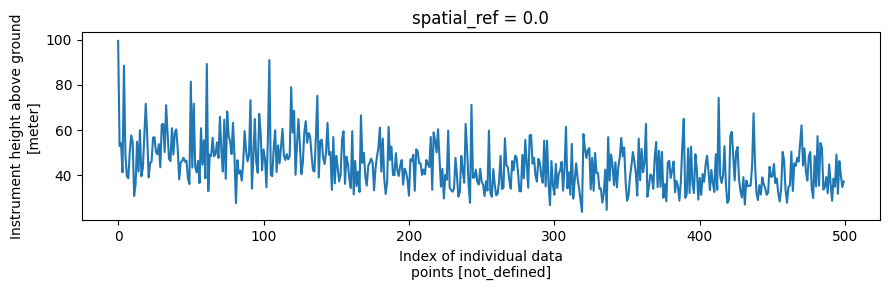

In [33]:
plt.figure(figsize=(9, 3))
reopened['data']['raw_data']['height'].plot()
plt.tight_layout()

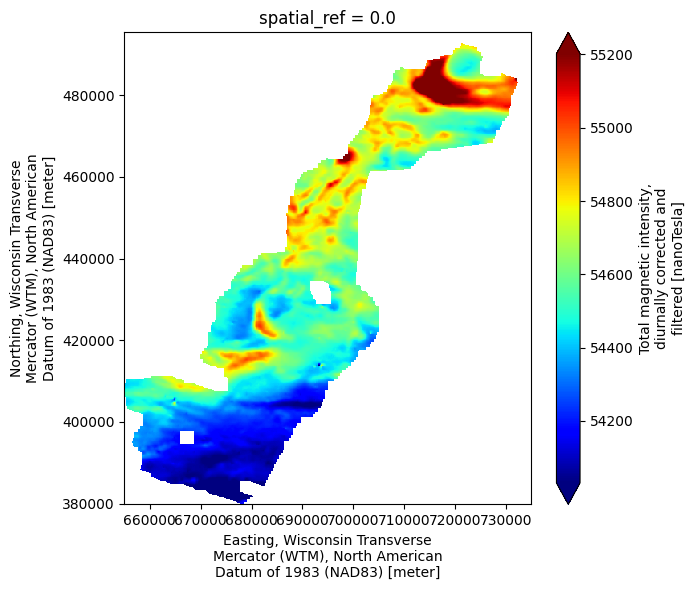

In [34]:
plt.figure(figsize=(7, 6))
reopened['derived_maps']['maps']['magnetic_tmi'].plot(cmap='jet', robust=True)
plt.tight_layout()

---
### Exercise 7.1

Plot the depth to bedrock grid, and then make a scatter plot of the bedrock
picks coloured by their elevation.

*Hint: the grid variable is `bedrock_depth` in `derived_maps/maps`. For the
scatter, GSPy adds `.gs.scatter(hue=...)` to tabular datasets - look at
`reopened['data']['depth_to_bedrock']` to find a variable to colour by.*

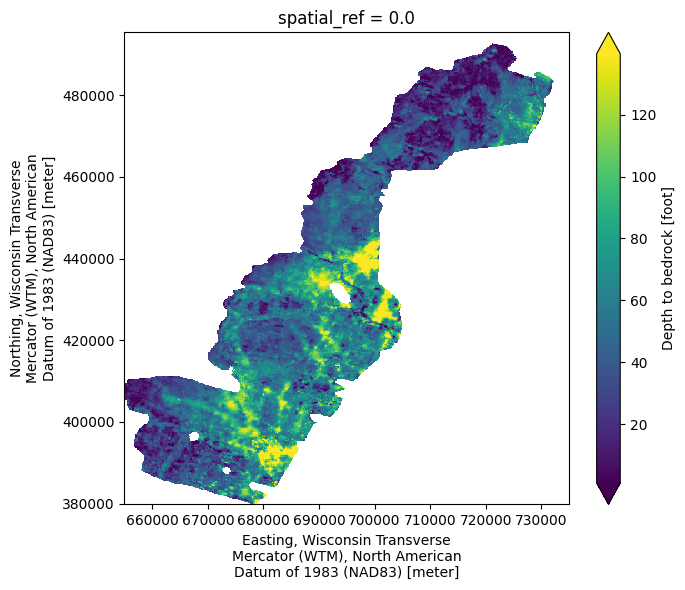

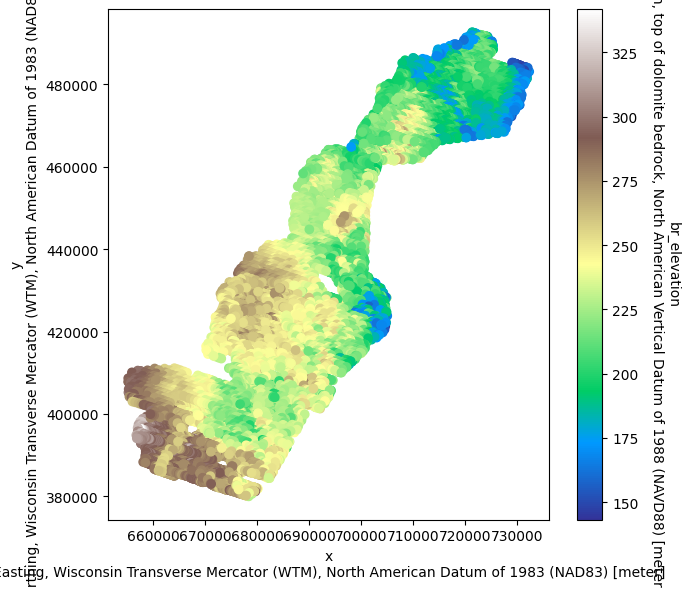

In [35]:
# --------------------------------------------------------------------
# EXERCISE - complete the lines marked with ...
# --------------------------------------------------------------------
plt.figure(figsize=(7, 6))
reopened['derived_maps']['maps']['bedrock_depth'].plot(cmap='viridis', robust=True)
plt.tight_layout()

plt.figure(figsize=(7, 6))
reopened['data']['depth_to_bedrock'].gs.scatter(hue='br_elevation', cmap='terrain')
plt.tight_layout()

---
---
## Where next

You started with four CSVs, four GeoTIFFs and no idea what any of it meant.
You now have one file that answers every question from section 1 in a single
line of code.

Two things worth taking away:

1. **`metadata_template()` is the way in.** You never have to write a GS
   metadata file from a blank page. Generate the skeleton, fill in the `??`,
   and let the error messages tell you what is still missing.
2. **The metadata is a one-time cost.** Filling in 34 variables is tedious
   once. Every future use of the data - by you, by a colleague, by
   software - reads it for free.

Next: **`2_tempest_aseg.ipynb`** walks the same path for an ASEG-GDF survey,
where the file format carries its own column definitions and the template
comes back mostly filled in already.

- GSPy documentation: https://doi-usgs.github.io/gspy
- The examples this workshop is built from live in `examples/` in the gspy
  repository.